# 02 SAM Segmentation

Initial Week 1 SAM test on one P&ID tile. This notebook loads the SAM `vit_l` checkpoint, runs automatic mask generation, visualizes raw masks, and saves one overlay image for review.

In [1]:
from pathlib import Path
import json

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from segment_anything import SamAutomaticMaskGenerator, sam_model_registry

plt.rcParams["figure.figsize"] = (12, 12)
plt.rcParams["axes.grid"] = False


In [2]:
REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATASET_ROOT = Path(r"C:\Users\jimmy\Downloads\pidset")
IMAGE_DIR = DATASET_ROOT / "images (3)"
LABEL_DIR = DATASET_ROOT / "labels (2)"
CHECKPOINT_PATH = REPO_ROOT / "checkpoints" / "sam_vit_l_0b3195.pth"
OUTPUT_DIR = REPO_ROOT / "outputs" / "overlays"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXAMPLE_IMAGE_NAME = "9_640_640.jpg"
EXAMPLE_IMAGE_PATH = IMAGE_DIR / EXAMPLE_IMAGE_NAME

for path in [REPO_ROOT, DATASET_ROOT, IMAGE_DIR, CHECKPOINT_PATH, EXAMPLE_IMAGE_PATH]:
    print(path, "->", path.exists())


C:\Users\jimmy\Documents\Tài liệu\vital docs\CODING\Python\diagram-cognitive-twin -> True
C:\Users\jimmy\Downloads\pidset -> True
C:\Users\jimmy\Downloads\pidset\images (3) -> True
C:\Users\jimmy\Documents\Tài liệu\vital docs\CODING\Python\diagram-cognitive-twin\checkpoints\sam_vit_l_0b3195.pth -> True
C:\Users\jimmy\Downloads\pidset\images (3)\9_640_640.jpg -> True


## Helper Functions

In [3]:
def load_image_rgb(image_path: Path) -> np.ndarray:
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def show_anns(anns, ax, alpha: float = 0.35):
    if not anns:
        return

    sorted_anns = sorted(anns, key=lambda ann: ann["area"], reverse=True)
    overlay = np.ones((sorted_anns[0]["segmentation"].shape[0], sorted_anns[0]["segmentation"].shape[1], 4))
    overlay[:, :, 3] = 0

    rng = np.random.default_rng(42)
    for ann in sorted_anns:
        mask = ann["segmentation"]
        color = np.concatenate([rng.random(3), [alpha]])
        overlay[mask] = color

    ax.imshow(overlay)


def masks_to_dataframe(anns: list[dict]) -> pd.DataFrame:
    rows = []
    for idx, ann in enumerate(anns):
        bbox_x, bbox_y, bbox_w, bbox_h = ann["bbox"]
        rows.append(
            {
                "candidate_id": idx,
                "bbox_x": bbox_x,
                "bbox_y": bbox_y,
                "bbox_w": bbox_w,
                "bbox_h": bbox_h,
                "area": ann["area"],
                "predicted_iou": ann.get("predicted_iou"),
                "stability_score": ann.get("stability_score"),
                "crop_box": ann.get("crop_box"),
                "point_coords": ann.get("point_coords"),
            }
        )
    return pd.DataFrame(rows)


def save_overlay_figure(image: np.ndarray, anns: list[dict], output_path: Path):
    fig, ax = plt.subplots(figsize=(12, 12))
    ax.imshow(image)
    show_anns(anns, ax)
    ax.set_title(f"SAM raw masks: {EXAMPLE_IMAGE_NAME}")
    ax.axis("off")
    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


## Load Image and SAM Model

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
print("torch:", torch.__version__)
print("torch cuda build:", torch.version.cuda)

image = load_image_rgb(EXAMPLE_IMAGE_PATH)
print("image shape:", image.shape)

sam = sam_model_registry["vit_l"](checkpoint=str(CHECKPOINT_PATH))
sam.to(device=device)
print("SAM vit_l loaded successfully")


device: cpu
torch: 2.13.0+cpu
torch cuda build: None
image shape: (1280, 1280, 3)
SAM vit_l loaded successfully


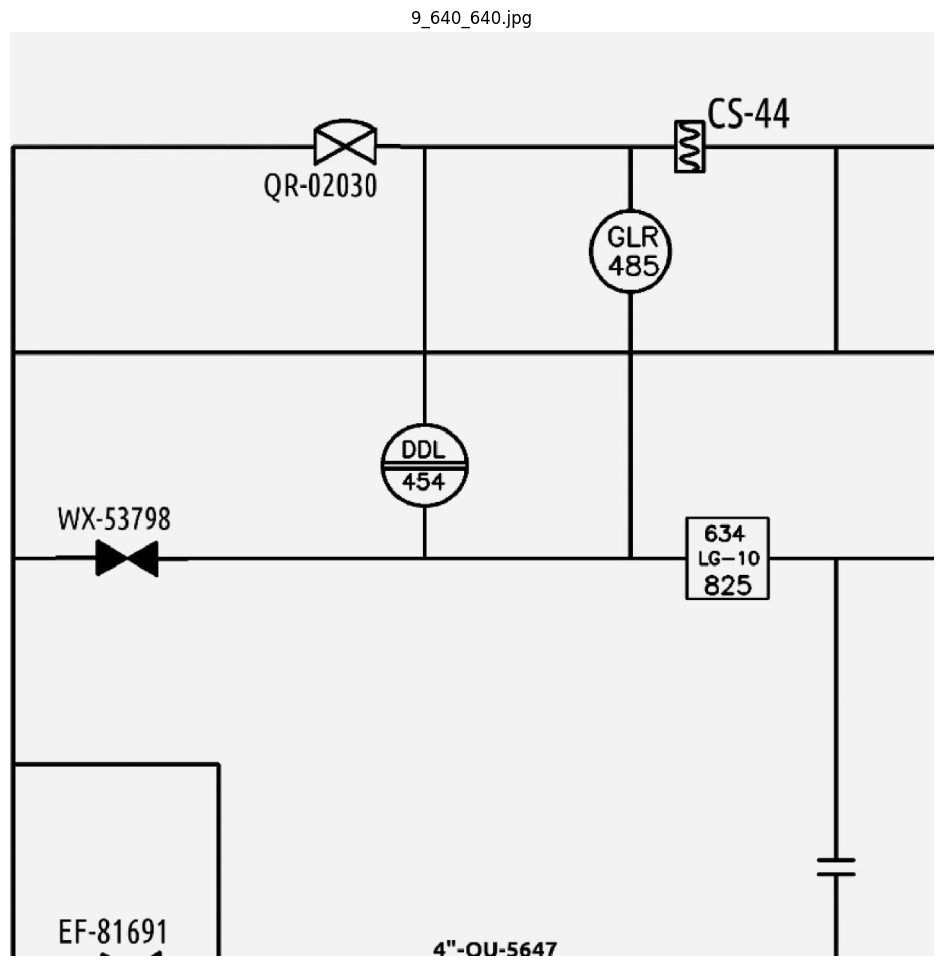

In [5]:
plt.imshow(image)
plt.title(EXAMPLE_IMAGE_NAME)
plt.axis("off");

## Automatic Mask Generation

In [6]:
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,
    pred_iou_thresh=0.86,
    stability_score_thresh=0.92,
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=100,
)

masks = mask_generator.generate(image)
print(f"raw mask count: {len(masks)}")

raw mask count: 62


In [7]:
mask_df = masks_to_dataframe(masks)
mask_df = mask_df.sort_values(by="area", ascending=False).reset_index(drop=True)
mask_df.head(15)

,candidate_id,bbox_x,bbox_y,bbox_w,bbox_h,area,predicted_iou,stability_score,crop_box,point_coords
0,57,0,91,1279,1188,1436955,0.971205,0.947202,"[0, 0, 1280, 1280]","[[780.0, 1180.0]]"
1,56,10,733,1232,546,524996,0.991617,0.977431,"[0, 0, 1280, 1280]","[[1060.0, 740.0]]"
2,58,9,449,1270,275,313805,0.942314,0.946346,"[0, 0, 1280, 1280]","[[540.0, 500.0]]"
3,61,10,449,1269,550,312687,0.870911,0.923596,"[0, 0, 1280, 1280]","[[1100.0, 460.0]]"
4,32,0,0,1279,153,186557,1.008634,0.987331,"[0, 0, 1280, 1280]","[[1100.0, 60.0]]"
5,49,7,163,562,276,153525,0.990904,0.973111,"[0, 0, 858, 858]","[[563.0625, 187.6875]]"
6,50,9,449,559,275,142515,0.984031,0.941295,"[0, 0, 858, 858]","[[509.4375, 616.6875]]"
7,14,864,449,415,275,107850,1.004312,0.993064,"[422, 0, 858, 858]","[[877.8125, 670.3125]]"
8,8,5,1012,286,267,76186,1.004609,0.989229,"[0, 422, 858, 858]","[[26.8125, 1253.1875]]"
9,55,1149,734,130,545,70281,0.996669,0.963368,"[422, 422, 858, 858]","[[1253.1875, 824.1875]]"


## Raw Mask Visualization

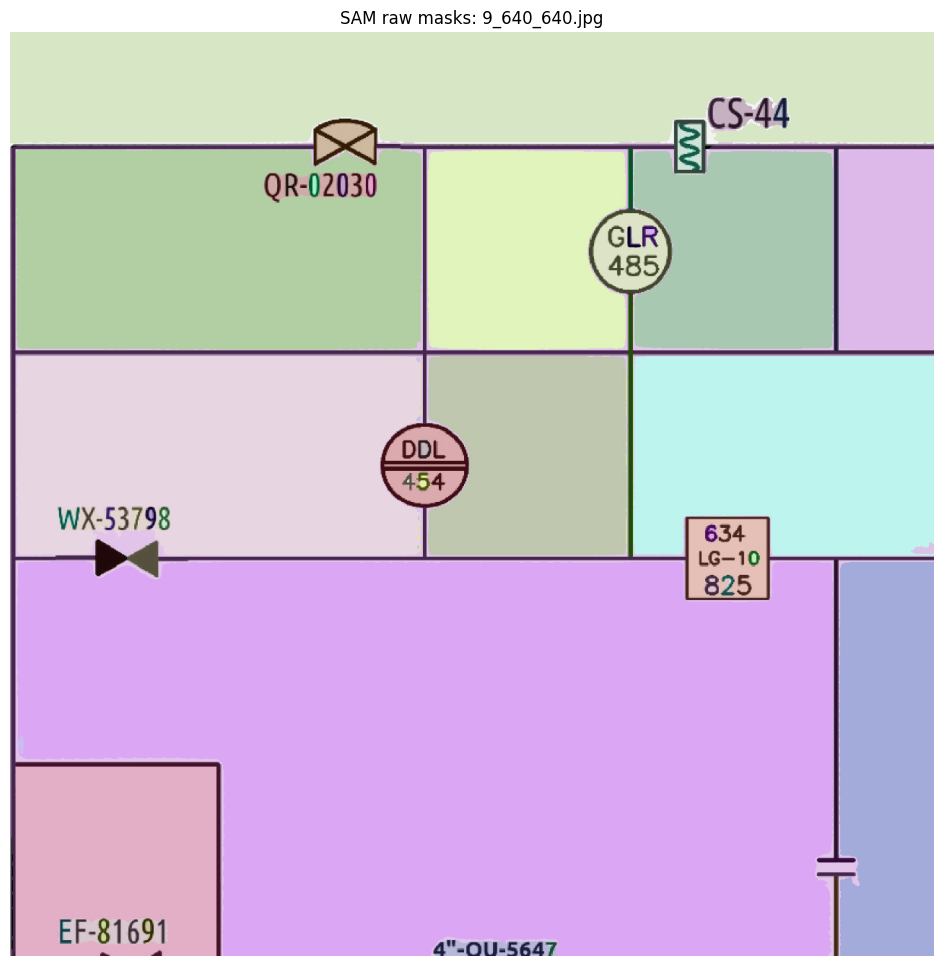

In [8]:
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(image)
show_anns(masks, ax)
ax.set_title(f"SAM raw masks: {EXAMPLE_IMAGE_NAME}")
ax.axis("off");

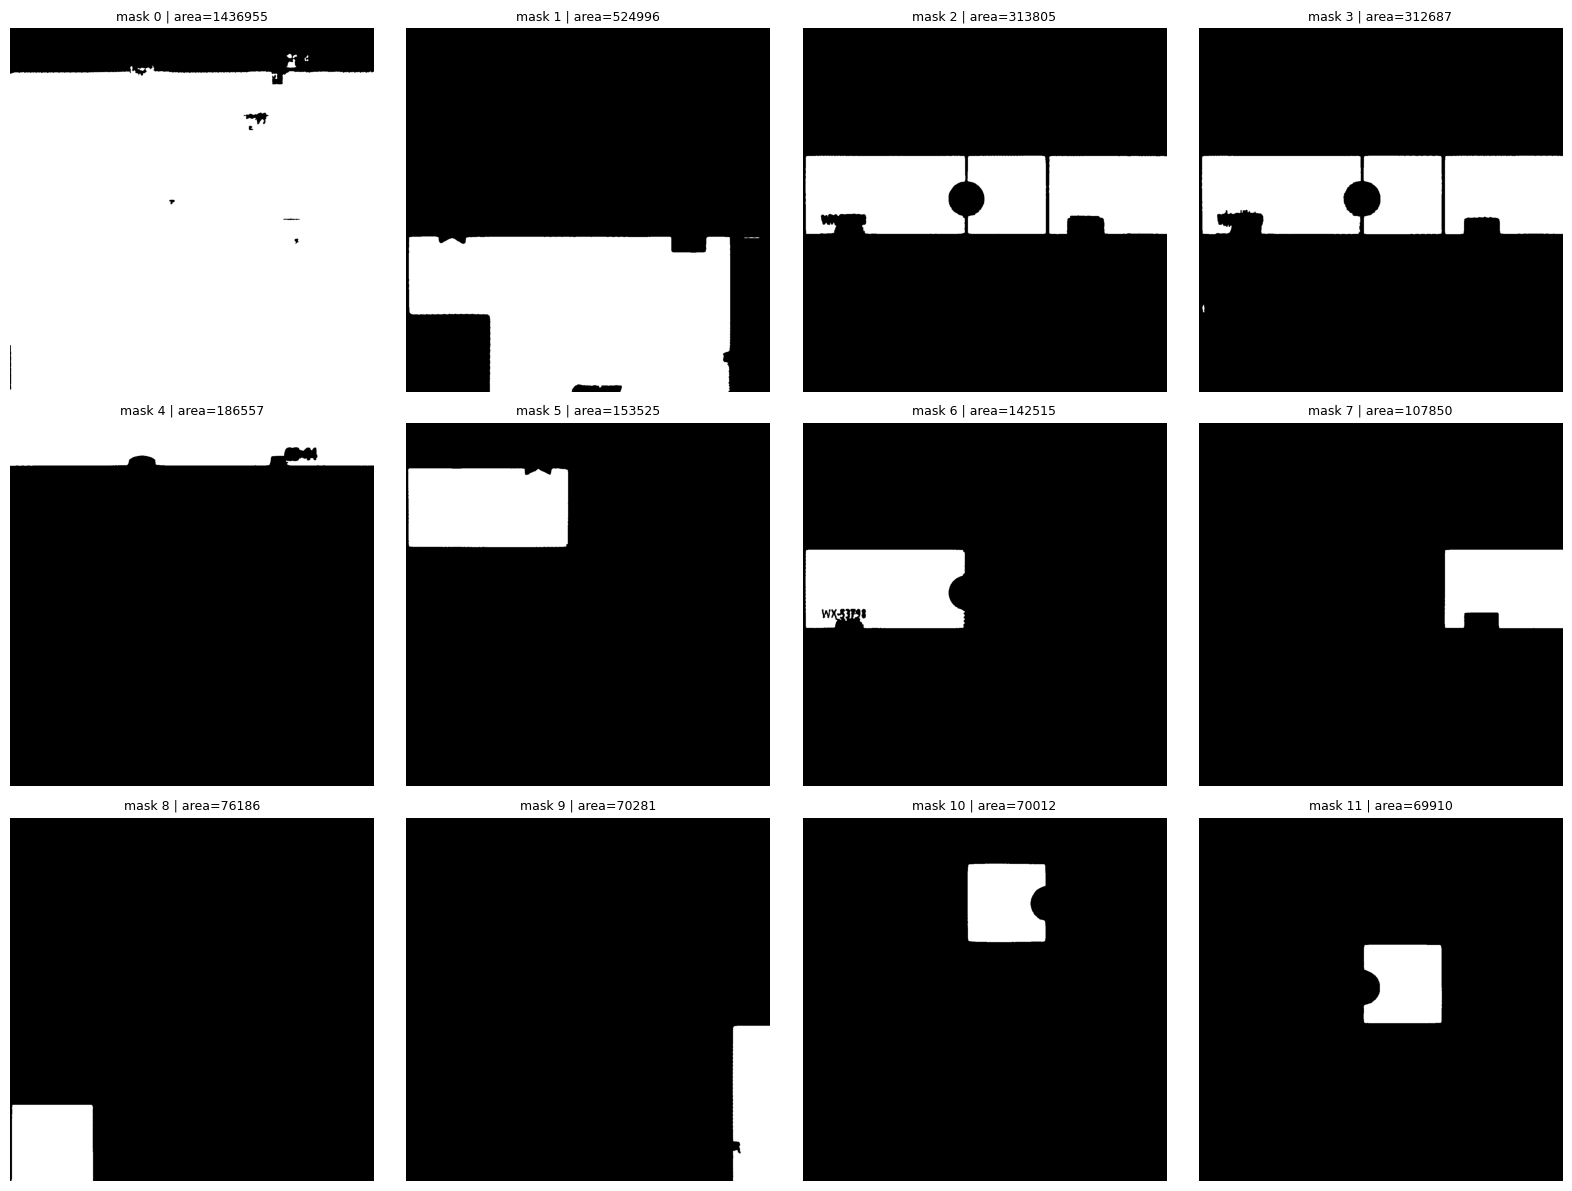

In [13]:
top_n = min(12, len(masks))
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for idx, ax in enumerate(axes.flat):
    if idx >= top_n:
        ax.axis("off")
        continue

    ann = sorted(masks, key=lambda item: item["area"], reverse=True)[idx]
    segmentation = ann["segmentation"]
    ax.imshow(segmentation, cmap="gray")
    ax.set_title(f"mask {idx} | area={ann['area']}", fontsize=9)
    ax.axis("off")

plt.tight_layout()

## Save One Raw-Mask Overlay

In [10]:
overlay_path = OUTPUT_DIR / f"{Path(EXAMPLE_IMAGE_NAME).stem}_sam_raw_overlay.png"
save_overlay_figure(image, masks, overlay_path)
print("saved overlay:", overlay_path)

saved overlay: C:\Users\jimmy\Documents\Tài liệu\vital docs\CODING\Python\diagram-cognitive-twin\outputs\overlays\9_640_640_sam_raw_overlay.png


## Initial Observations

Fill this in after the notebook run.

- Raw mask count:
- Did SAM produce page/background masks?
- Did SAM break symbols into multiple fragments?
- Did SAM strongly segment text?
- Which obvious symbol types look recoverable?
- Next parameter change to test:
